## ECE 161C Laboratory Notebooks
---

This Juypter notebook is part of a series of computer laboratories which are designed
to teach image-processing programming. They are the practical complement of the theoretical lectures of the UCSD's course 
[**ECE 161C**](https://canvas.ucsd.edu/courses/75498) taught by Prof. Rahul Parhi.

---
# Lab 2: Filtering and Morphology Implementation and Applications
**Released**: Monday, May 4, 2026 
**Due**: Wednesday, May 13, 2026 at 11:55pm

### Download the images on Colab

In [ ]:
!git clone --depth 1 --filter=blob:none --sparse https://github.com/sparsity-group/161c-release.git /content/repo
%cd /content/repo
!git sparse-checkout set 2_Filtering_Morphology_Lab/images
!cp -r /content/repo/2_Filtering_Morphology_Lab/images /content/images
%cd /content

## Imports
Run the next two cells to import the libraries and load the images that we will use throughout the lab.

In [ ]:
# install opencv if not present already
!pip install opencv-python

In [ ]:
# restart the kernal if you get the error: ModuleNotFoundError: No module named 'cv2'
import cv2 as cv

In [ ]:
# Import other standard required packages for this exercise
import matplotlib.pyplot as plt
import numpy as np
import scipy.ndimage as ndi
import skimage
import scipy.stats
import seaborn as sns

# Load images to be used in this exercise 
bikesgray = skimage.io.imread('images/bikesgray.tif').astype('float64')
camera = skimage.io.imread('images/camera-16bits.tif').astype('float64')
spots = skimage.io.imread('images/spots.tif').astype('float64')

Creating dictionary for all answers

In [ ]:
answers = {} # dictionary for storing answers

# Filtering (6 points)

In this lab, you will review the basics of digital image filtering: how to implement a convolution (the main ingredient of filtering), separable and non-separable filters, filter design, and boundary conditions. The goal is to fully understand the filtering algorithm at a pixel-by-pixel level by implementing it in Python, and learn the standard tools to use filtering in professional image-processing libraries in Python.

# Visualize images
Display and get familiar with the images.

In [ ]:
# Function to display multiple images using Matplotlib
def display_images(images, titles):
    num_images = len(images)
    fig, axes = plt.subplots(1, num_images, figsize=(5 * num_images, 5))
    
    if num_images == 1:
        axes = [axes]  # Ensure axes is iterable
    
    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img, cmap='gray')
        ax.set_title(title)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
image_list = [bikesgray, camera, spots]
titles = ["Bikes Gray", "Camera", "Spots"]

display_images(image_list, titles)

# 1. Implementation and classification of digital filters (6 points)

In this exercise, we will practice the implementation and classification of digital filters. Moreover, you will practice separable and non-separable implementations in Python. You'll implement 6 functions in Python that correspond to 6 different digital filters. Each of them takes an input image and outputs the filtered version of it. You need to
* hard code the mask inside the function,
* apply the filtering using either `ndi.convolve` and `ndi.convolve1d`, depending on if the filter is separable.

You can define 1D and 2D filters as 1D and 2D numpy arrays, e.g.
```python
mask = np.array([1, 2])
```
```python
mask = np.array([[ 1,  2], 
                 [ 6,  7]])
```

Implementing each function is worth **0.5 points**, classifing their visual effect is worth **0.5 points**.


<b>Important:</b> If a mask is separable and you don't implement it as such, you'll not get the points.


Note on the separability of filters:

Some filters, in particular simple edge detector filters can intuitively be recognized as separable. Furthermore, their $1\mathrm{D}$ masks can also be intuitively proposed. From these $1\mathrm{D}$ masks, a simple test consists in taking the matrix product between them, which should result in the original filter. However, there is a more systematic approach. As you should know, any matrix $\mathbf{\mathrm{M}}\in\mathbb{R}^{m\times n}$ can be factorized into its components $\mathbf{\mathrm{USV^{T}}}$ by Singular Value Decomposition, where $\mathbf{\mathrm{U}}\in\mathbb{R}^{m\times m}$, $\mathbf{\mathrm{S}}\in\mathbb{R}^{\min(m, n)\times \min(m, n)}$ corresponds to a diagonal matrix with the singular values of $\mathbf{\mathrm{M}}$, and $\mathbf{\mathrm{V}}\in\mathbb{R}^{n\times n}$. It follows from the definition of the matrix product that if only one singular value is larger than zero, the filter is separable.
Nonetheless, for simple filters, we still recommend you to use the <i>intuitive</i> filters. If you want to extract the filters using SVD, you can use the <a href="https://numpy.org/doc/stable/reference/generated/numpy.linalg.svd.html"><code>svd</code></a> function of the NumPy Linear Algebra package. We leave you the task of extracting the actual $1\mathrm{D}$ masks from it.<font> 


## 1.A. Mask A (1 point)

In the cell below, **For 0.5 points**, implement the function `filter_A`, which convolves the input image with the mask 

```python3
    [ 0,  0,   1,  0,  0]
    [ 0,  1,   2,  1,  0]
A = [ 1,  2, -16,  2,  1]
    [ 0,  1,   2,  1,  0]
    [ 0,  0,   1,  0,  0]
```

In [2]:
# Function that filters img with the mask A
def filter_A(img):
    output = img.copy()

    # YOUR CODE HERE
    
    return output

Run the next cell to visualize the result of applying `filter_A` to the image `bikesgray`.

In [ ]:
bikesgray_A = filter_A(bikesgray)
plt.close('all')

display_images([bikesgray, bikesgray_A], ["Original", "Convolved with filter A"])

**For 0.5 points** answer the following MCQ:

Q1: Which of the following keywords best describes the visual effect of this filter?

1. isotropic blurring
2. vertical blurring
3. horizontal blurring
4. diagonal blurring
5. sharpening
6. vertical-edge detection
7. horizontal-edge detection
8. diagonal edge detection
9. Laplacian: a second order derivative to find edges (maxima and minima)
10. it has no effect

In [ ]:
# Assign your answer to this variable
answers['Q1'] = None

In [ ]:
assert answers['Q1'] in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 'Possible answers are 1 to 10'

## 1.B. Mask B (1 point)

In the cell below, **For 0.5 points**, implement the function `filter_B`, which convolves the input image with the mask 

```python3
    [ 0,  1,  2,  1,  0]
    [ 1,  2,  4,  2,  1]
B = [ 2,  4,  8,  4,  2]
    [ 1,  2,  4,  2,  1]
    [ 0,  1,  2,  1,  0]
```

In [ ]:
# Function that filters img with the mask B
def filter_B(img):
    output = img.copy()
       
    # YOUR CODE HERE
    
    return output

Run the next cell to visualize the result of applying `filter_B` to the image `bikesgray`.

In [ ]:
bikesgray_B = filter_B(bikesgray)
plt.close('all')
display_images([bikesgray, bikesgray_B], ['Original', 'Filtered with mask B'])

**For 0.5 points** answer the following MCQ:

Q2: Which of the following keywords best describes the visual effect of this filter?

1. isotropic blurring
2. vertical blurring
3. horizontal blurring
4. diagonal blurring
5. sharpening
6. vertical-edge detection
7. horizontal-edge detection
8. diagonal edge detection
9. Laplacian: a second order derivative to find edges (maxima and minima)
10. it has no effect

In [ ]:
# Assign your answer to this variable
answers['Q2'] = None

In [ ]:
assert answers['Q2'] in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 'Possible answers are 1 to 10'

## 1.C. Mask C (1 point)

In the cell below, **For 0.5 points**, implement the function `filter_C`, which convolves the input image with the mask 

```python3
    [-1,  -1,  -1,  -1,  -1]
    [-2,  -2,  -2,  -2,  -2]
C = [ 0,   0,   0,   0,   0]
    [ 2,   2,   2,   2,   2]
    [ 1,   1,   1,   1,   1]
```

Remember to check if the filter is separable, and in that case, implement it in that way.

In [ ]:
# Function that filters img with the mask C
def filter_C(img):
    output = img.copy()
    
    # YOUR CODE HERE
    
    return output

Run the next cell to visualize the result of applying `filter_C` to the image `bikesgray`.

In [ ]:
bikesgray_C = filter_C(bikesgray)
plt.close('all')
display_images([bikesgray, bikesgray_C], ['Original', 'Filtered with mask C'])

**For 0.5 points** answer the following MCQ:

Q3: Which of the following keywords best describes the visual effect of this filter?

1. isotropic blurring
2. vertical blurring
3. horizontal blurring
4. diagonal blurring
5. sharpening
6. vertical-edge detection
7. horizontal-edge detection
8. diagonal edge detection
9. Laplacian: a second order derivative to find edges (maxima and minima)
10. it has no effect

In [ ]:
# Assign your answer to this variable
answers['Q3'] = None

In [ ]:
assert answers['Q3'] in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 'Possible answers are 1 to 10'

## 1.D. Mask D (1 point)

In the cell below, **For 0.5 points**, implement the function `filter_D`, which convolves the input image with the mask 

```python3
    [-1,  -4,  -6,  -4, -1]
    [-4, -16, -24, -16, -4]
D = [-6, -24, 476, -24, -6]
    [-4, -16, -24, -16, -4]
    [-1,  -4,  -6,  -4, -1]
```

In [ ]:
# Function that filters img with the mask D
def filter_D(img):
    output = img.copy()
    
    # YOUR CODE HERE
    
    return output

Run the next cell to visualize the result of applying `filter_D` to the image `bikesgray`.

In [ ]:
bikesgray_D = filter_D(bikesgray)
plt.close('all')
display_images([bikesgray, bikesgray_D], ['Original', 'Filtered with mask D'])

**For 0.5 points** answer the following MCQ:

Q4: Which of the following keywords best describes the visual effect of this filter?

1. isotropic blurring
2. vertical blurring
3. horizontal blurring
4. diagonal blurring
5. sharpening
6. vertical-edge detection
7. horizontal-edge detection
8. diagonal edge detection
9. Laplacian: a second order derivative to find edges (maxima and minima)
10. it has no effect

In [ ]:
# Assign your answer to this variable
answers['Q4'] = None

In [ ]:
assert answers['Q4'] in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 'Possible answers are 1 to 10'

## 1.E. Mask E (1 point)

In the cell below, **For 0.5 points**, implement the function `filter_E`, which convolves the input image with the mask 

```python3
    [0, 0, 0, 0, 0]
    [0, 0, 0, 0, 0]
E = [0, 0, 1, 0, 0]
    [0, 0, 0, 0, 0]
    [0, 0, 0, 0, 0]
```
Remember to check if the filter is separable, and in that case, implement it in that way.

In [ ]:
# Function that filters img with the mask E
def filter_E(img):
    output = img.copy()
    
    # YOUR CODE HERE
    
    return output

Run the next cell to visualize the result of applying `filter_E` to the image `bikesgray`.

In [ ]:
bikesgray_E = filter_E(bikesgray)
plt.close('all')
display_images([bikesgray, bikesgray_E], ['Original', 'Filtered with mask E'])

**For 0.5 points** answer the following MCQ:

Q5: Which of the following keywords best describes the visual effect of this filter?

1. isotropic blurring
2. vertical blurring
3. horizontal blurring
4. diagonal blurring
5. sharpening
6. vertical-edge detection
7. horizontal-edge detection
8. diagonal edge detection
9. Laplacian: a second order derivative to find edges (maxima and minima)
10. it has no effect

In [ ]:
# Assign your answer to this variable
answers['Q5'] = None

In [ ]:
assert answers['Q5'] in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 'Possible answers are 1 to 10'

## 1.F. Mask F (1 point)

In the cell below, **For 0.5 points**, implement the function `filter_f`, which convolves the input image with the mask 


```python3
    [ 0, -1, -1,  0,  0]
    [-1, -1,  0,  0,  0]
F = [-1,  0,  0,  0,  1]
    [ 0,  0,  0,  1,  1]
    [ 0,  0,  1,  1,  0]
```

In [ ]:
# Function that filters img with the mask F
def filter_F(img):
    output = img.copy()
    
    # YOUR CODE HERE
    
    return output

Run the next cell to visualize the result of applying `filter_F` to the image `bikesgray`.

In [ ]:
bikesgray_F = filter_F(bikesgray)
plt.close('all')
display_images([bikesgray, bikesgray_F], ['Original', 'Filtered with mask F'])

**For 0.5 points** answer the following MCQ:

Q6: Which of the following keywords best describes the visual effect of this filter?

1. isotropic blurring
2. vertical blurring
3. horizontal blurring
4. diagonal blurring
5. sharpening
6. vertical-edge detection
7. horizontal-edge detection
8. diagonal edge detection
9. Laplacian: a second order derivative to find edges (maxima and minima)
10. it has no effect

In [ ]:
# Assign your answer to this variable
answers['Q6'] = None

In [ ]:
assert answers['Q6'] in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 'Possible answers are 1 to 10'

# Filtering applications (9 points)

After the [first part](./1_Filtering.ipynb) of the lab, we expect you to feel comfortable with the basics of filtering. In this part we will look in detail at the implementation of a Gaussian filter, as well as some of its direct applications. Gaussian filters are known to be near-optimal smoothing filters, and represent perhaps the most used preprocessing step in image processing to improve robustness in a workflow and to denoise images.

# 2. Gaussian filter (4 points)

An [isotropic 2D Gaussian](https://en.wikipedia.org/wiki/Multivariate_normal_distribution) is represented by its impulse response,

$$h_\sigma(x,y) = \frac{1}{2\pi\sigma^2}\exp\left(-\frac{x^2 + y^2}{2\sigma^2}\right) \overset{\mathrm{separability}}{=} \frac{1}{\sqrt{2\pi}\sigma}\exp\left(-\frac{x^2}{2\sigma^2}\right) \frac{1}{\sqrt{2\pi}\sigma}\exp\left(-\frac{ y^2}{2\sigma^2}\right) \,,$$

where $\sigma$ is the standard deviation and controls the smoothing strength.

In this section, you will implement a 2D Gaussian filter with impulse response $h_{\sigma}[m,n]$, which discretizes $h_\sigma(x,y)$ between $[-\lceil3\sigma\rceil,\lceil 3\sigma\rceil]$ in $x$ and $y$. Here, $\lceil x \rceil$ refers to ceiling: the smallest integer larger than a given $x\in\mathbb{R}$. 

Choose the size of the filter to be $N = 2\lceil 3\sigma \rceil+1$ (hence, $N$ is always odd), and **ensure the impulse response adds up to $1$**, using appropriate normalization.

## 2.A. Implementation of a 2D Gaussian filter (3 points)

For **2 points**, implement the function `gaussian(img, sigma)` that convolves an image with a Gaussian filter using a **separable implementation**. Take advantage of [ndi.convolve1d](https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.convolve1d.html). 

In [ ]:
# Function that performs a Gaussian filter with sigma on img
def gaussian(img, sigma):
    img_filtered = np.zeros(img.shape)
    
    # YOUR CODE HERE
    

    return img_filtered


We have designed a quick test for you to evaluate your method, applying it to a 
 impulse image. Run the following cell and check that your output has all the desired properties of a Gaussian.

In [ ]:
# Create an impulse image (5x5) with a single center pixel set to 1
impulse = np.zeros((5, 5))
impulse[2, 2] = 1

# Apply Gaussian filter with sigma = 0.5
impulse_gaussian = gaussian(impulse, 0.5)

# Display the result
plt.imshow(impulse_gaussian, cmap='gray')
plt.title('Impulse Response of Gaussian Filter')
plt.colorbar()
plt.show()

# Perform sanity checks
if impulse_gaussian[2, 2] < impulse_gaussian[2, 3] or not np.isclose(impulse_gaussian[2, 1], impulse_gaussian[2, 3]):
    print("WARNING!!!\nThere are still some mistakes with your implementation! Look at the sanity checks to understand the mistakes.")
else:
    print("The symmetry of the Gaussian seems good. (further testing will be done later)")

# Check normalization
if not np.isclose(impulse_gaussian.sum(), 1, atol=1e-5):
    print("WARNING!!\nNormalization not correct")
else:
    print("Well done! The output sums up to approximately 1.")


We will apply your Gaussian filter to the image `bikesgray` using various values of $\sigma$. You can observe the changes in the mean and standard deviation by using the functions `np.mean` and `np.std`. 

Run and modify the cell below to apply Gaussian filters with different $\sigma$ values to `bikesgray` and view the result. Then, answer the two multiple choice questions.

<div class="alert alert-danger">
<b>Important:</b> don't forget to change $\sigma$ to a normal (small) value after your exploration!
</div>

In [ ]:
# YOUR CODE HERE
sigma = 10

In [ ]:
# Apply Gaussian filter to the image with different sigma values
bikesgray_gaussian_sigma = gaussian(bikesgray, sigma)

# Show results
display_images([bikesgray, bikesgray_gaussian_sigma], ['Original', f"Sigma: {sigma}"])

### Multiple Choice Question

After modifying the sigma in one cell above and visualizing the results, **For 0.5 points** answer the following MCQ:

* Q7: How will the Fourier transform of an image change after applying a Gaussian filter?
    1. It will have lower values for higher frequencies.
    2. It will have higher values for higher frequencies.
    3. It will have lower values for lower frequencies.
    4. It will not change.

In [ ]:
# Assign your answer to this variable
answers['Q7'] = None

In [ ]:
assert answers['Q7'] in [1, 2, 3, 4], 'Possible answers are 1 to 4'

**For 0.5 points** answer the following MCQ:

* Q8: What will be the output image when $\sigma\rightarrow \infty$? What type of filter would that be?
    1. An image equal to the original. It would be an all-pass filter.
    2. A constant image. It would be a high-pass filter.
    3. A 2D Gaussian. It would be a band-pass filter.
    4. A constant image. It would be a low-pass filter.

In [ ]:
# Assign your answer to this variable
answers['Q8'] = None

In [ ]:
assert answers['Q8'] in [1, 2, 3, 4], 'Possible answers are 1 to 4'

## 2.B. Gaussian filter in Python (1 point)

There are several implementations of Gaussian filters in Python. In this section, we will use the `scikit-image` implementation [`skimage.filters.gaussian`](https://scikit-image.org/docs/dev/api/skimage.filters.html#skimage.filters.gaussian). Here is an example how to use it:

```python
output = skimage.filters.gaussian(input, sigma=10, mode='reflect', truncate=3, preserve_range=True)
```
The above line specifies that we apply on the `input` image a Gaussian filter with $\sigma=10$, reflective boundary condition, truncated to $3\sigma$ range and keep the original range of values of `input`.


In the next cells, we will apply it to the image `bikesgray` and compare it to your implementation. 

In [ ]:
bikesgray_gaussian_skimage = skimage.filters.gaussian(bikesgray, sigma=10 , mode='reflect', truncate=3, preserve_range=True)
# Display the result
display_images([bikesgray_gaussian_skimage], ["Gaussian Filter (skimage)"])

Now, we will compare it to your implementation to make sure that they are equivalent (up to errors on the order of $10^{-14}$). For this, we call the `gaussian` function you implemented with the image `bikesgray`, also for $\sigma = 10$.

If the images are not the same, you can look at the difference image with differing regions in red to help identify mistakes.  

In [ ]:
# Apply custom Gaussian filter implementation
bikesgray_gaussian_custom = gaussian(bikesgray, sigma=10)

# Compute the absolute difference
difference = np.abs(bikesgray_gaussian_skimage - bikesgray_gaussian_custom)

# Display both images and the difference
image_list = [bikesgray_gaussian_skimage, bikesgray_gaussian_custom, difference]
titles = ["Skimage Gaussian", "Custom Gaussian", "Difference (Error Visualization)"]
display_images(image_list, titles)

# Compute max absolute error
max_error = np.max(difference)
print(f"Maximum absolute error: {max_error:.2e}")

# Sanity check
if max_error > 1e-5:
    print("WARNING: There may be an issue in your implementation!")
else:
    print("Your implementation matches skimage's Gaussian filter.")


# 3. Application: Spot detector (5 points)

Now, we will apply Gaussian filtering to create a *spot detector* using the Difference of Gaussians (DoG) filter, which is an approximation of the Laplacian-of-Gaussian (LoG) filter. We will perform these tasks using **only Python libraries**.

To detect spots, we will compute the local maximum on the output of the DoG filter. In the upcoming exercises, we will work with an image called `spots`. Run the next cell to visualize the image.

<div class = 'alert alert-success'>
<b>Note</b>: At first, it may seem tempting to use a simple thresholding approach to detect <i><u>bright</u></i> spots, given their higher intensity compared to the rest of the image. However, by hovering your mouse around the image and examining the pixel values, you will quickly realize that there exists no such threshold. This is precisely why we need to use more sophisiticated techniques. Moreover, the <i>spot detector</i> you will code is robust to noise, and to changing pixel values accross images. 

In [ ]:
plt.close('all')
display_images([spots], ["spots"])

## 3.A. Difference of Gaussians (2 points)

The DoG is constructed from the subtraction of two Gaussian functions, i.e., $\mathrm{DoG}(x) = h_{\sigma_{1}}(x) - h_{\sigma_2}(x)$. It is usually parametrised only by $\sigma_1$, and $\sigma_2$ is chosen as $\sigma_2 = \sqrt{2}\sigma_1$. 

Experiment with the value of $\sigma_1$ in the next cell to see the kind of profile generated by this filter in 1D.

In [ ]:
# Choose sigmas: use values in range of 0.5 to 5
sigma_1 = 0.5

In [ ]:
# sigma_2 based on sigma_1 value
sigma_2 = sigma_1 * np.sqrt(2)

# Compute x values
x = np.arange(-3 * sigma_2, (3 + 6.0 / 100) * sigma_2, 6 * sigma_2 / 100)

# Compute Gaussian and Difference of Gaussians
gaussian_1 = scipy.stats.norm(scale=sigma_1).pdf(x)
gaussian_2 = scipy.stats.norm(scale=sigma_2).pdf(x)
dog = gaussian_1 - gaussian_2

# Plot
plt.figure(figsize=(10, 4))
plt.plot(x, gaussian_1, label=r"$h_{\sigma_1}(x)$")
plt.plot(x, gaussian_2, label=r"$h_{\sigma_2}(x)$")
plt.plot(x, dog, label=r"$\mathrm{DoG}_{\sigma_1}(x)$")
plt.xlabel(r"$x$")
plt.xlim([-20, 20])
plt.ylim([-0.1, 0.8])
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

For **1 point**, modify the next cell and write the function `dog`, that takes as input an image and the value of $\sigma_1$, then outputs the normalized DoG of this image so that its intensity is in the range$[0,1]$. **You should hardcode the value of $\sigma_2 = \sigma_1\sqrt{2}$ inside the function**. 


<div class = 'alert alert-info'>
    <b>Note</b>: Check the documentation of the <code>skimage.filters.gaussian</code> function <a href='https://scikit-image.org/docs/stable/api/skimage.filters.html#skimage.filters.gaussian'>here</a>.  <b>Make sure you use the correct parameters</b>, like <code>preserve_range = True</code> option, truncating the filter at $3\sigma$ (so $N = 2\lceil 3\sigma \rceil+1$), and using <code>'reflect'</code> or equivalent boundary conditions.
</div>

Complete the function `dog` in the next cell, where we have also included an initial sanity check.

In [ ]:
def dog(image, sigma_1):
    output = np.copy(image)
    
    # YOUR CODE HERE
    
    return output

err_message = "Remember to normalize the output so that it spans the range [0,1]."
assert dog(spots, 1).max() == 1, err_message
assert dog(spots, 1).min() == 0, err_message

In the next two cells, you can visualize the results of your function for different $\sigma_1$ values, modify the value of $\sigma_1$.  

In [ ]:
# Choose sigmas: use values in range of 0.5 to 10
sigma_1 = 3.0

In [ ]:
dog_image = dog(spots, sigma_1)
display_images([dog_image], ["dog_image"])

### Multiple choice question
**For 0.5 points** answer the following MCQ:

Q9: What type of filter is the DoG?

    1. Low-pass  
    2. Band-pass  
    3. High-pass  


In [ ]:
# Assign your answer to this variable
answers['Q9'] = None

In [ ]:
assert answers['Q9'] in [1, 2, 3], 'Possible answers are 1 to 3'

**For 0.5 points** answer the following MCQ:

Q10: Which $\sigma$ would you choose to highlight the spots?

    1. 1.5  
    2. 5  
    3. 10 

In [ ]:
# Assign your answer to this variable
answers['Q10'] = None

In [ ]:
assert answers['Q10'] in [1, 2, 3], 'Possible answers are 1 to 3'

## 3.B. Local maxima (1 point)

Now you will write the function `local_max(img, T)` that returns a binary image. In a $3\times 3$ neighborhood, this function will set the pixels which are a local maximum to $255$ and rest to $0$. A local maximum in a $3\times 3$ neighborhood is a pixel that has a value strictly greater than its 8 closest neighbors (8-connected) and is strictly greater than a threshold $T$ (specified between $0$ and $1$, relative to the maximum of the image).

<b>Hint:</b> 8-connected pixels are neighbors to every pixel that touches one of their edges or corners.<br>

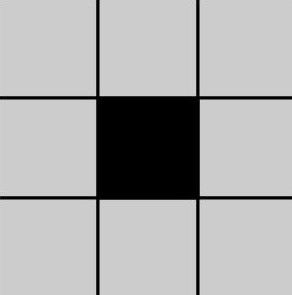


The function <code>skimage.feature.peak_local_max</code> (<a href = 'https://scikit-image.org/docs/0.7.0/api/skimage.feature.peak'>see documentation here</a>) is useful. Remember you don't need and shouldn't use for-loops in this exercise!

  
For **1 point**, modify the next cell to define your function.

In [ ]:
# Function that computes the local max in a 3x3 nbh
def local_max(img, T):
    output = np.zeros(img.shape)
    
    # YOUR CODE HERE
    
    return output

Run the next cell for a quick test on your function. We test  that your image applied to `camera` with a threshold $T = 0.5$ detects exactly the four maximum points of the image, as it should. If the assertion raises no error, your function is most probably correct.

In [ ]:
if np.count_nonzero(local_max(camera, 0.5)) in [4, 5]:
    print('Congratulations! Your function passed this sanity check.')
else :
    print('WARNING!!\nYour function is not working on the image `cameras` as it should.')

Run the next cell to test it on the image `camera`. 

Then modify the next cell to look at the result of your function applied to the image `spots`. Is the function able to detect the **6 spots**?  

<div class = 'alert alert-info'>
<b>Note</b>: Try this for the image 'camera'. You might notice a somewhat strange behaviour with the bright pixel located at the bottom of the image. Do you know why is this happening? If you don't, have a closer look at the documentation of <code>feature.peak_local_max</code>! 
</div>

In [ ]:
# Choose threshold: use values in range of 0 and 1
threshold = 0.8

In [ ]:
loc_max_image = local_max(spots, threshold)
display_images([spots, loc_max_image], ["spots", "local_max_image"])

## 3.C. Spot detector (2 points)

For **1.5 point**, implement the method `spot_detector(img, sigma, T)`, where you use your previous two functions to detect spots. In other words, apply the detection of local maxima on the output of the DoG filter.

In [ ]:
# Function that detects spots in img, using sigma and a threshold T
def spot_detector(img, sigma, T):
    output = img.copy()
    
    # YOUR CODE HERE
    
    return output

Run the next cell for a quick test on your function.

In [ ]:
if not np.count_nonzero(spot_detector(spots, 1, 0.3)) == 6:
    print('WARNING!!!\nYour function is not yet correct. First make sure that `dog` and `local_max` are.')
else :
    print('Congratulations! Your spot detector seems to be correct.')

Now, let's apply your function to the image `spots` using the set values of $\sigma_1$ and $T$ in the cell below. Run the following cell, and play with these values.

In [ ]:
# Choose sigma and threshold
sigma = 1
threshold = 0.5

In [ ]:
spot_detector_image = spot_detector(spots, sigma, threshold)
display_images([spots, spot_detector_image], ["spots", "spot_detector_image"])

### Multiple Choice Question

**For 0.5 points** answer the following MCQ:

Q11: What pair of parameters will give you exactly 6 spots? If there are more than one, try to select the one that works better if the image was slightly perturbed.

1. $\sigma_1 = 10$ and $T = 0.2$
2. $\sigma_1 = 5$ and $T = 0.6$
3. $\sigma_1 = 5$ and $T = 0.2$
4. $\sigma_1 = 1$ and $T = 0.3$

Modify the variable answer in the next cell to reflect your choice. Run the last cell to check that your answer is valid.

In [ ]:
# Assign your answer to this variable
answers['Q11'] = None

In [ ]:
assert answers['Q11'] in [1, 2, 3, 4], 'Possible answers are 1 to 4'

# Morphology Implementations (12 points)

In the first part of this laboratory, you will learn

1. how to implement several morphological filters in Python, and
2. how to apply them in image processing applications using [`OpenCV`](https://opencv.org/).

We will focus mainly on 2D gray-level morphology, but keep in mind that the same operations can easily be adapted to color images by treating each color channel as an independent gray-level image.

# 4. Structuring elements (2 points)

As you have seen in the course, a structuring element (often abbreviated with `strel` in the code) can be described by a binary image consisting of a foreground and a background, which are usually represented with `True` (or `1`) and `False` (or `0`), respectively. They are used in morphological filters such as dilation, erosion, opening, closing, and all others that are derived from those. The purpose of the structuring element is to define the shape and size used by a morphological filter. **Your task in this section is to implement 2 different structuring elements, namely a cross and a disc.**

**For 1 point each**, implement the functions `cross(n)` and `disc(n)` to build the shapes of the structuring elements of size `n × n`. The function `square(n)` is provided and serves as a reference. The "disc" shape contains elements that are inside a circle tangent to the frame of the `n × n` square, and the "cross" shape contains a horizontal and a vertical line that meet in the center of the square, both with a single-pixel width.

The images below show an example of how the different elements should look with a size of `9 × 9`.

| *Examples of how a correct `9×9` cross, disc and square structuring elements look like.* |

⚠️ **Note: The proposed structuring elements are all symmetric and** _you only need to implement for odd `n`_, **it is not necessary to reflect the structuring element as we would do in a generic implementation. However, you can still do it if you want.**


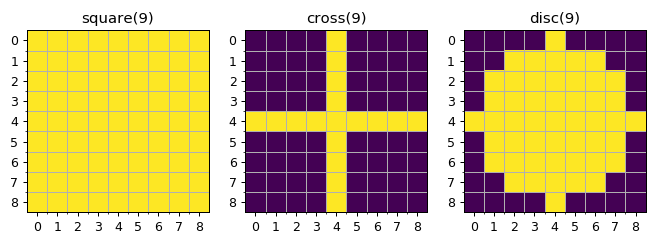

In [ ]:
plate = cv.imread('images/plate.tif', cv.IMREAD_UNCHANGED)
butterfly = cv.imread('images/butterfly-graylevel.tif', cv.IMREAD_UNCHANGED)

## 4.A. Square structuring element

The next cell provides the example function `square(n)`, which returns a square of size `n × n` filled with `1`s.

In [ ]:
# Function that takes an integer n and returns an n x n array of 1s.
def square(n):
    return np.ones((n, n), dtype=int)

The next cell runs the function `square(n)` and stores the result in the variable `strel_square` which is displayed in another cell. Feel free to experiment with the size passed to the function and observe the results.

In [ ]:
# Runs the function above
strel_square = square(9)

Run the next cell to use Python to display the structuring element as an image.

In [ ]:
def display_structuring_element(strel, title):
    """Displays a binary image with a title and numerated pixel grid."""
    plt.figure(figsize=(5,5))
    sns.heatmap(strel, cmap='viridis', cbar=False, linewidths=0.5, linecolor='gray', annot=True, fmt="d")
    plt.title(title)
    plt.show()

# Display the structuring element
display_structuring_element(strel_square, f'Square structuring element of size {strel_square.shape}')

When working in Python, we can use the [OpenCV](https://docs.opencv.org/master/) library to generate structuring elements and perform image processing tasks.

To use OpenCV (called `cv2` in Python for historical reasons) it is best practice to import it as `cv`, which has already been done in the previous cell of the notebook. When using the morphological filters provided by OpenCV, the structuring element that should be passed to the functions is a `numpy` array. We can either define it ourselves using NumPy, for example, a $9 \times 9$ square as in the cell below.

In [ ]:
# Create a 9x9 square structuring element using NumPy
strel_square_custom = np.ones((9,9), dtype=int)

or we can use [`cv.getStructuringElement()`](https://docs.opencv.org/trunk/d4/d86/group__imgproc__filter.html#gac342a1bb6eabf6f55c803b09268e36dc), which takes as input parameters:
* `shape`: [`cv.MORPH_RECT`](https://docs.opencv.org/master/d4/d86/group__imgproc__filter.html#gac2db39b56866583a95a5680313c314ad) to generate a rectangle, [`cv.MORPH_ELLIPSE`](https://docs.opencv.org/master/d4/d86/group__imgproc__filter.html#gac2db39b56866583a95a5680313c314ad) to generate an ellipse, [`cv.MORPH_CROSS`](https://docs.opencv.org/master/d4/d86/group__imgproc__filter.html#gac2db39b56866583a95a5680313c314ad) to generate a cross, and
* `ksize`: The shape of the structuring element, e.g. `(9, 9)`

You can look at the documentation for a full description of the function. Run the next cell to get the same $9 \times 9$ square we defined above.

In [ ]:
# Create a 9x9 square structuring element using OpenCV
strel_square_cv = cv.getStructuringElement(cv.MORPH_RECT, ksize=(9,9))

We can compare the two structuring elements (NumPy, OpenCV) visually:

In [ ]:
# Close existing figures to release memory
plt.close('all')

# Display the three structuring elements side by side to compare them
fig, axes = plt.subplots(1, 2, figsize=(15,5))

titles = ['Custom NumPy Array', 'OpenCV']
elements = [strel_square_custom, strel_square_cv]

for ax, strel, title in zip(axes, elements, titles):
    sns.heatmap(strel, cmap='viridis', cbar=False, linewidths=0.5, linecolor='gray', annot=True, fmt="d", ax=ax)
    ax.set_title(title)

plt.show()


or numerically, to make sure all the implementations provide the same result by using the `assert` statement, as in the cell below.

**Note: [`np.allclose(arr1, arr2)`](https://numpy.org/doc/stable/reference/generated/numpy.allclose.html) returns `True` if `arr1` and `arr2` are equal to a certain tolerance.**

In [ ]:
# Compare the NumPy version to the OpenCV version
assert np.allclose(strel_square, strel_square_custom), 'The NumPy versions do not agree.'
assert np.allclose(strel_square, strel_square_cv), 'The NumPy and OpenCV versions do not agree.'

print('Indeed, all structuring elements are exactly the same.')

## 4.B. Cross structuring element (1 point)

Now it's your turn! In the cell below, **for 1 point**, complete the code in python to implement the `cross(n)` function.

💡 *Hint: You can use integer division (//) to find the center of the cross. Remember that your implementation only needs to work for odd `n` (this is true for the whole section).*

In [ ]:
# Function that takes an integer n and returns an n x n cross structuring element.
def cross(n):    
    if n % 2 == 0:
        raise ValueError("n must be odd to create a proper cross shape.")

    # Create an n x n array filled with zeros
    output = np.zeros((n, n), dtype=int)

    # YOUR CODE HERE

    return output

Now run the following $2$ cells to generate a $9\times 9$ structuring element and visualize it. Feel free to change the size in the next cell.

In [ ]:
# Generate a cross structuring element of size 9x9
strel_cross = cross(9)

In [ ]:
# Display the structuring element
display_structuring_element(strel_cross, f'Cross structuring element of size {strel_cross.shape}')

In Python, we have several ways of generating a cross structuring element. One, using only NumPy is to generate an array of zeros and use advanced indexing to set the middle row/column to $1$. However, OpenCV also offers us a straightforward way by passing `cv.MORPH_CROSS` to `getStructuringElement`. Run the cell below to create and display the OpenCV cross. You can also change the size of the structuring element and see the result.

In [ ]:
# Generate the cross structuring element with OpenCV - feel free to play with the size
strel_cross_cv = cv.getStructuringElement(cv.MORPH_CROSS, ksize=(9, 9))

# Display it
display_structuring_element(strel_cross_cv, f'OpenCV cross of size {strel_cross_cv.shape}')

The following cell tests if the Python (NumPy) and OpenCV structuring elements are identical. To make sure you pass the test, **verify that both are of the same size**!

⚠️ **Note: Throughout this section, we will give you the freedom to choose the size of the structuring element. However, if you do change it, make sure to change it back to the original for the following comparisons. This is true for every exercise. When you hand in your notebook, all comparison cells should run without any errors.**

In [ ]:
# Compare the NumPy version to the OpenCV version
assert strel_cross.shape == strel_cross_cv.shape, f"WARNING! The size of the two structuring elements is not the same: NumPy={strel_cross.shape}, OpenCV={strel_cross_cv.shape}"
assert np.allclose(strel_cross, strel_cross_cv), "WARNING! The two structuring elements are not the same."

# If everything is OK, print a success message
print("Yes! The crosses are identical.")

## 4.C. Disc structuring element (1 point)

In the cell below, **for 1 point**, complete the code in Python to implement the `disc(n)` function.

In [ ]:
# Function that takes an integer n and returns a disc structuring element of size (n x n).
def disc_custom(n):
    # Create an n x n array filled with zeros
    output = np.zeros((n, n), dtype=int)

    # YOUR CODE HERE
     
    return output

Now run the following cell to generate a 9×9 disc structuring element and visualize it. Feel free to change the size and observe the result.

In [ ]:
# Generate a disc structuring element of size 9x9
strel_disc = disc_custom(9)

In [ ]:
# Display the structuring element
display_structuring_element(strel_disc, f'Disc structuring element of size {strel_disc.shape}')

Unfortunately, OpenCV doesn't provide a disc structuring element. However, it provides elliptical structuring elements by passing `cv.MORPH_ELLIPSE` to `getStructuringElement`. Usually, an ellipse that has the same height and width should be just a normal circle/disc, so let's see what happens if we generate such a disc using OpenCV's ellipse generator. Run the cell below to generate an OpenCV interpretation of a disc.

In [ ]:
# Generate an ellipse with height = width
strel_ellipse = cv.getStructuringElement(cv.MORPH_ELLIPSE, ksize=(9,9))

# Display the result
display_structuring_element(strel_ellipse, "OpenCV's definition of a disc")

Does your implementation look different from the *disc* in the cell above? If so, don't worry, you didn't do anything wrong. As you can hopefully see, this isn't a circular disc, but still some kind of ellipse, even though the height and width are set to the same value. Either this is a bug in the implementation of `getStructuringElement()` or they simply have another interpretation of a circle (which is wrong). Anyhow, the lesson here is, do not trust anything blindly. This means we need to create our own function in Python to generate a disc structuring element. Luckily for you, we have already done this.

**Note: Because it is very inefficient to use for loops in Python (and you should only do it if necessary!), this task was implemented using a [`lambda` function](https://docs.python.org/3/tutorial/controlflow.html#lambda-expressions) and the NumPy function [`np.fromfunction`](https://numpy.org/doc/stable/reference/generated/numpy.fromfunction.html).**
    
For the scope of this lab, you do not need to understand the `lambda` function. However, we do recommend you to go through the documentation and completely understand the following cell -- it will improve your programming skills!

Run the next cell to declare the function `disc(n)`.

In [ ]:
# Function that generates a disc structuring element in python
def disc(n):
    # Define the function of a circle as a lambda function
    circle_func = lambda i, j: ((i - n//2)**2 + (j - n//2)**2) <= (n//2)**2
    # Set all elements of the array that are inside the circle of diameter n to 1 - np.uint8 to match the type used by OpenCV for structuring elements
    output = np.fromfunction(circle_func, shape=(n,n)).astype(np.uint8)
    # Return the structuring element
    return output

Now run the next one to declare a circular structuring element. Feel free to change `n`, and look at the effect.

In [ ]:
# Here we generate a disc structuring element with python by calling the function implemented above
strel_disc_python = disc(9)
# And display it
plt.close('all')
display_structuring_element(strel_disc_python, "Python disc implementation")

Now that we have a working function to compare your implementation to, lets do it! Run the cell below to test your implementation.

In [ ]:
# Compare the Python NumPy disc with OpenCV’s version
assert strel_disc.shape == strel_ellipse.shape, f"WARNING! The sizes of the structuring elements are not the same: NumPy={strel_disc.shape}, OpenCV={strel_ellipse.shape}"
assert np.allclose(strel_disc, strel_ellipse) == False, "WARNING! The Python disc and OpenCV ellipse appear identical, but they should not be."

print("Well done! Your disc is better than that of OpenCV.")


# 5. Morphological filters (10 points)

In this part, you are asked to implement the morphological filters given in the table below. Click on their names for a quick link to where you have to implement them.

| $\text{Filter}$ | $\text{Function}$ | $\text{Definition / Mathematical notation}$   |
|------------|---------------|----------------------------------------------------------|
| [Erosion](#5.A.-Erosion)              (5.A) | `erosion()`   | $f \ominus b$                                            |
| [Dilation](#5.B.-Dilation)            (5.B) | `dilation()`  | $f \oplus b$                                             |
| [Median](#5.C.-Median-filter)         (5.C) | `median()`    | $\mathrm{MED}(f, b)$                                     |
| [Open](#5.D.-Opening)                 (5.D) | `open()`      | $f \circ b = (f \ominus b) \oplus b$                     |
| [Close](#5.E.-Closing)                (5.E) | `close()`     | $f \bullet b = (f \oplus b) \ominus b$                   |
| [Gradient](#5.F.-Gradient-filter)     (5.F) | `gradient()`  | $\bigtriangledown (f, b) = (f \oplus b) - (f \ominus b)$ |
| [Top-hat](#5.G.-Top-hat-filter)       (5.G) | `topHat()`    | $\mathrm{TH}(f, b) = f - (f \circ b)$                    |
| [Bottom-hat](#5.H.-Bottom-hat-filter) (5.H) | `bottomHat()` | $\mathrm{BH}(f, b) = (f \bullet b) - f$                  |

Each function is worth **1 point**. You will start by implementing the most basic morphological filters: `erosion()`, `dilation()`, and `median()` and compare them to the OpenCV equivalents. The rest will be implemented in Python. The results of your implementation will be shown on the images `plate` and `butterfly`.

## 5.A. Erosion (1 point)

In the cell below, **for 1 point**, complete the code in Python to implement the `erosion(img, b)`.

Remember from your course notes, given an image $f$ with support $\Omega_f$ and a structuring element $b$ with support $\Omega_b$, we define erosion as

$$
    (f \ominus b)[\mathbf{k}] = \min_{\mathbf{q}\in\Omega_b}\left\lbrace f\left[\mathbf{k} + \mathbf{q}\right] \mid (\mathbf{k}+\mathbf{q})\in\Omega_f \right\rbrace\,.
$$
 
As we mentioned before, because all the structuring elements are symmetric and $N$ is odd, you need not worry about reflecting them.

OpenCV has implemented the function [`cv.erode`](https://docs.opencv.org/4.5.3/d4/d86/group__imgproc__filter.html#gaeb1e0c1033e3f6b891a25d0511362aeb), which we can use to erode an image with a custom structuring element. The main parameters are:
 * `src`: The original image, 
 * `kernel`: The structuring element, 
 * `borderType`: The boundary conditions. 
 
We encourage you to look at the [documentation](https://docs.opencv.org/4.5.3/d4/d86/group__imgproc__filter.html#gaeb1e0c1033e3f6b891a25d0511362aeb) for more details.
You might find some other interesting parameters, such as `iterations`. 
    
It is best practice to explicitly declare arguments to Python functions when using image processing libraries -- except for the original image, as it is always the first one -- as we have been doing with `cv.getStructuringElement`. This is because the optional arguments are not necessarily in the order in which we will use them, and explicit declaration can avoid confusion (e.g. `cv.erode(img, kernel=b, borderType=cv.BORDER_REFLECT)` is not the same as `cv.erode(img, b, cv.BORDER_REFLECT)`! If you go through the documentation, you will see that there is the parameter `dst` in between them.

In [ ]:
# Performs an erosion operation on the image 'img' using the structuring element 'b'
def erosion(img, b):
    output = img.copy()
    # YOUR CODE HERE
    
    return output

In [ ]:
# Define the structuring element
b = cv.getStructuringElement(cv.MORPH_RECT, ksize=(5,5)) 

Run the next cell to apply the `erosion()` function to the images `plate` and `butterfly`.

In [ ]:
plate_erosion = erosion(plate, b)
butterfly_erosion = erosion(butterfly, b)

Run the next cell to visualize the results.

In [ ]:
display_images(
    [plate, butterfly, plate_erosion, butterfly_erosion],
    ['Original Plate', 'Original Butterfly', 'Eroded Plate', 'Eroded Butterfly'])

## 5.B. Dilation (1 point)

In the cell below, **for 1 point**, complete the code to implement the `dilation(img, b)`.

Remember that in the course, given an image $f$ with support $\Omega_f$ and a structuring element $b$ with support $\Omega_b$, we define dilation as

$$
    (f \oplus b)[\mathbf{k}] = \max_{\mathbf{q}\in\Omega_b}\left\lbrace f\left[\mathbf{k} - \mathbf{q}\right] \mid (\mathbf{k}-\mathbf{q})\in\Omega_f \right\rbrace\,.
$$

As we did for the erosion, in Python we can use [`cv.dilate`](https://docs.opencv.org/4.5.3/d4/d86/group__imgproc__filter.html#ga4ff0f3318642c4f469d0e11f242f3b6c) to dilate an image `img` with a structuring element `b`. The input arguments are the same as for `cv.erode`.

In [ ]:
# Performs a dilation operation on the image 'img' using the structuring element 'b'.
def dilation(img, b):
    output = img.copy()
    
    # YOUR CODE HERE
     
    return output

In [ ]:
# Define the structuring element
b = cv.getStructuringElement(cv.MORPH_RECT, ksize=(5,5))  # Feel free to modify this

Now run the next two cells to dilate the images `plate` and `butterfly` and see the results. 

In [ ]:
plate_dilation = dilation(plate, b)
butterfly_dilation = dilation(butterfly, b)

In [ ]:
display_images(
    [plate, butterfly, plate_dilation, butterfly_dilation],
    ['Original Plate', 'Original Butterfly', 'Dilated Plate', 'Dilated Butterfly'])

## 5.C. Median filter (1 point)

In the cell below, **for 1 point**, complete the code to implement the `median()` filter.

Remember that in the course, given an image $f$ with support $\Omega_f$ and a structuring element $b$ with support $\Omega_b$, we define the median filter as

$$
    \mathrm{MED}(f, b)[\mathbf{k}] = \mathrm{median}\left( \left\lbrace f\left[\mathbf{k} - \mathbf{q}\right] \mid \mathbf{q}\in\Omega_b, (\mathbf{k}-\mathbf{q})\in\Omega_f \right\rbrace \right)\,.
$$

Here, $\mathrm{median}(\cdot)$ is a function that computes the median of a set of pixel values in the neighborhood defined by the structuring element 𝑏.


To apply a median filter to an image `img` with an $n \times n$ **square** structuring element using OpenCV, we can use [`cv.medianBlur(img, ksize=n)`](https://docs.opencv.org/4.5.3/d4/d86/group__imgproc__filter.html#ga564869aa33e58769b4469101aac458f9). Run the cell below to compare your median to the OpenCV median.

**Note: In OpenCV, the median filter can only be applied with a square structuring element, and uses "repeat padding" at the border, i.e., it repeats the last pixel. That means that you just coded a more versatile median filter than the one from one of the most recognized image-processing libraries!**

In [ ]:
# Performs a median filter operation on the image 'img' using the structuring element 'b'.
def median(img, b):
    output = img.copy()
    
    # YOUR CODE HERE
    
    return output

Apply the `median()` function to the images plate and butterfly.

In [ ]:
plate_median = median(plate, b)
butterfly_median = median(butterfly, b)

Visualize the Results

In [ ]:
# Display original and median filtered images
display_images(
    [plate, butterfly, plate_median, butterfly_median],
    ['Original Plate', 'Original Butterfly', 'Median Filtered Plate', 'Median Filtered Butterfly'])

Now let's take a moment to look at the [morphological filters' table](#3.-Morphological-filters-(9-points)), given at the beginning of Part 3. There, you will see that all the morphological filters that we have not implemented yet are simple combinations of some of those that we have implemented, namely `dilation` and `erosion`. The idea of this lab is for you to understand how morphological filters work.

## 5.D. Opening (1 point)

In the cell below, **for 1 point**, implement the `open()` function **using only the [`cv.dilate`](https://docs.opencv.org/4.5.3/d4/d86/group__imgproc__filter.html#ga4ff0f3318642c4f469d0e11f242f3b6c) and [`cv.erode`](https://docs.opencv.org/4.5.3/d4/d86/group__imgproc__filter.html#gaeb1e0c1033e3f6b891a25d0511362aeb) functions presented above**.

⚠️ **Note: To be consistent, make sure you use `cv.BORDER_REFLECT` as the border type for all functions.**

In [ ]:
# Function that performs an opening on the image 'img' using the structuring element 'b'
def opening(img, b):
    # Declaring the output image
    AoB = np.zeros(img.shape)
    
    # YOUR CODE HERE
    
    return AoB

In [ ]:
# Here we declare the structuring element
b = cv.getStructuringElement(cv.MORPH_RECT, ksize=(5,5)); # Feel free to change it to your liking (using the functions presented in part 1) and observe the results.

# Directly run the function on the two images
plate_open = opening(plate, b)
butterfly_open = opening(butterfly, b)

# and also display the result
# Define the lists of images and titles
images = [plate, butterfly, plate_open, butterfly_open]
image_names = ['plate', 'butterfly', 'plate opened', 'butterfly opened']
# Visualize them
# Display original and opened images
display_images(images,image_names)

Now let's compare your `open` function to the one that OpenCV provides. Using OpenCV, you can perform the opening of an image `img` with a structuring element `b` using [`cv.morphologyEx`](https://docs.opencv.org/4.5.2/d4/d86/group__imgproc__filter.html#ga67493776e3ad1a3df63883829375201f). Its main parameters are very similar to the other morphology related functions:
 * `src`: the original image, 
 * `op`: The operation to be performed (see OpenCV's [MorphTypes](https://docs.opencv.org/4.5.2/d4/d86/group__imgproc__filter.html#ga7be549266bad7b2e6a04db49827f9f32) list)
 * `kernel`: Structuring element to use, 
 * `borderType`: Boundary conditions.

Again we use `borderType=cv.BORDER_REFLECT` for consistency. Run the next cell to compare the functions.

⚠️ **Note: Of course, it is forbidden to use the function `cv.morphologyEx` inside your functions `opening`, `closing`, and `gradient`.**

In [ ]:
# Perform the opening on plate with OpenCV using the same structuring element b
plate_open_cv = cv.morphologyEx(src=plate, op=cv.MORPH_OPEN, kernel=b, borderType=cv.BORDER_REFLECT)
# Compare the two versions
if not np.allclose(plate_open, plate_open_cv): 
    print('WARNING!\nSorry, your opening does not match the opening of OpenCV.')
else :
    print("Great! Your opening gives the same result as OpenCV on the plate image.")

## 5.E. Closing (1 point)

In the cell below, **for 1 point**, implement the `close()` function **using only the [`cv.dilate`](https://docs.opencv.org/4.5.3/d4/d86/group__imgproc__filter.html#ga4ff0f3318642c4f469d0e11f242f3b6c) and [`cv.erode`](https://docs.opencv.org/4.5.3/d4/d86/group__imgproc__filter.html#gaeb1e0c1033e3f6b891a25d0511362aeb) functions presented above**.

In [ ]:
# Function that performs a closing on the image 'img' using the structuring element 'b'
def closing(img, b):
    # Declaring the output image
    AcB = np.zeros(img.shape)
    
    # YOUR CODE HERE
    
    return AcB

In [ ]:
# Here we declare the structuring element
b = cv.getStructuringElement(cv.MORPH_RECT, ksize=(5,5)); # Feel free to change it to your liking (using the functions discussed and implemented in part 1) and observe the results.

# Directly run the function on the two images
plate_close = closing(plate, b)
butterfly_close = closing(butterfly, b)

# and also display the result
# Define the lists of images and titles
images = [plate, butterfly, plate_close, butterfly_close]
image_names = ['plate', 'butterfly', 'plate closed', 'butterfly closed']
# Visualize them
plt.close('all')
display_images(images,image_names)

To perform the closing operation with OpenCV, we use `cv.MORPH_CLOSE` instead of `cv.MORPH_OPEN` in the `cv.morphologyEx` function presented above. Run the cell below to compare the functions.

In [ ]:
# Perform the closing on plate with OpenCV using the same structuring element b
plate_close_cv = cv.morphologyEx(src=plate, op=cv.MORPH_CLOSE, kernel=b, borderType=cv.BORDER_REFLECT)
# Compare the two versions
if not np.allclose(plate_close, plate_close_cv): 
    print('Sorry, your closing is not quite right.')
else:
    print("Great! Your closing gives the same result as OpenCV on the plate image.")

## 5.F. Gradient filter (1 point)
 
In the cell below, **for 1 point**, implement the `gradient()` function **using only the [`cv.dilate`](https://docs.opencv.org/4.5.3/d4/d86/group__imgproc__filter.html#ga4ff0f3318642c4f469d0e11f242f3b6c) and [`cv.erode`](https://docs.opencv.org/4.5.3/d4/d86/group__imgproc__filter.html#gaeb1e0c1033e3f6b891a25d0511362aeb) functions presented above** and basic arithmetics (`+`,`-`,`*`, or `/`).

💡 *Hint: Remember that in Python you can add/subtract whole images simply by using the $+/-$ operators, without the need to iterate with `for` loops.*

In [ ]:
# function that performs a gradient on the image 'img' using the structuring element 'b'
def gradient(img, b):
    # declaring the output image
    grad = np.zeros(img.shape)

    
    # YOUR CODE HERE
    
    return grad

In [ ]:
# here we declare the structuring element
b = cv.getStructuringElement(cv.MORPH_RECT, ksize=(5,5)); # Feel free to change it to your liking (using the functions discussed and implemented in part 1) and observe the results.

# directly run the function on the two images
plate_gradient = gradient(plate, b)
butterfly_gradient = gradient(butterfly, b)

# and also display the result
# define the lists of images and titles
images = [plate, butterfly, plate_gradient, butterfly_gradient]
image_names = ['plate', 'butterfly', 'plate gradient', 'butterfly gradient']
# visualize them
plt.close('all')
display_images(images, image_names)

In OpenCV, the identifier `cv.MORPH_GRADIENT` can be used to calculate the gradient with the `cv.morphologyEx` function presented above. Run the next cell to check your function.

In [ ]:
# Perform the gradient on plate with OpenCV using the same structuring element b
plate_gradient_cv = cv.morphologyEx(src=plate, op=cv.MORPH_GRADIENT, kernel=b, borderType=cv.BORDER_REFLECT)
# Compare the two versions
if not np.allclose(plate_gradient, plate_gradient_cv): 
    print('WARNING!\nSorry, your gradient is not quite right.')
else:
    print("Great! Your gradient operator produces the same result as OpenCV on the plate image.")

## 5.G. Top-hat filter (1 point)

In the cell below, **for 1 point**, implement the `topHat()` function by **using only the OpenCV functions we have seen in Tasks [5.A.](#5.A.-Erosion) to [5.E.](#5.E.-Closing)**.

⚠️ **Note: You are not allowed to use `cv.morphologyEx` with `cv.MORPH_TOPHAT` in this function.**

In [ ]:
# function that performs a topHat on the image 'img' using the structuring element 'b'
def topHat(img, b):
    # declaring the output image
    tophat = np.zeros(img.shape)
    
    # YOUR CODE HERE

    return tophat

In [ ]:
# here we declare the structuring element
b = cv.getStructuringElement(cv.MORPH_RECT, ksize=(5, 5)); # Feel free to change it to your liking (using the functions discussed and implemented in part 1) and observe the results.

# directly run the function on the two images
plate_tophat = topHat(plate, b)
butterfly_tophat = topHat(butterfly, b)

# and also display the result
# define the lists of images and titles
images = [plate, butterfly, plate_tophat, butterfly_tophat]
image_names = ['plate', 'butterfly', 'plate tophat', 'butterfly tophat']
# visualize them
plt.close('all')
display_images(images,image_names)

To perform the topHat filter in OpenCV, one uses `cv.MORPH_TOPHAT`. Run the cell below to check your function.

In [ ]:
# Perform the top hat on plate with OpenCV using the same structuring element b
plate_tophat_cv = cv.morphologyEx(src=plate, op=cv.MORPH_TOPHAT, kernel=b, borderType=cv.BORDER_REFLECT)
# Compare the two versions
if not np.allclose(plate_tophat, plate_tophat_cv): 
    print('Sorry, your topHat filter is not quite right.')
else :
    print("Great! Your topHat operator produces the same result as OpenCV on the plate image.")

## 5.H. Bottom-hat filter (1 point)

In the cell below, **for 1 point**, implement the `bottomHat()` function by **using only the OpenCV functions we have seen in Tasks [3.A.](#3.A.-Erosion) to [3.E.](#3.E.-Closing)**.

⚠️ **Note: You are not allowed to use `cv.morphologyEx` with `op=cv.MORPH_BLACKHAT` in this function.**

In [ ]:
# function that performs a bottomHat on the image 'img' using the structuring element 'b'
def bottomHat(img, b):
    # declaring the output image
    bottomhat = np.zeros(img.shape)

    
    # YOUR CODE HERE
    
    return bottomhat

In [ ]:
# here we declare the structuring element
b = cv.getStructuringElement(cv.MORPH_RECT, ksize=(5,5)); # Feel free to change it to your liking (using the functions discussed and implemented in part 1) and observe the results.

# directly run the function on the two images
plate_bottomhat = bottomHat(plate, b)
butterfly_bottomhat = bottomHat(butterfly, b)

# and also display the result
# define the lists of images and titles
images = [plate, butterfly, plate_bottomhat, butterfly_bottomhat]
image_names = ['plate', 'butterfly', 'plate bottomHat', 'butterfly bottomHat']
# visualize them
plt.close('all')
display_images(images,image_names)

In OpenCV we use `cv.MORPH_BLACKHAT` to perform a bottomHat filter. Run the next cell to check your function.

In [ ]:
# Perform the bottom hat on plate with OpenCV using the same structuring element b
plate_bottomhat_cv = cv.morphologyEx(plate, cv.MORPH_BLACKHAT, b, borderType=cv.BORDER_REFLECT)
# Compare the two versions
if not np.allclose(plate_bottomhat, plate_bottomhat_cv): 
    print('Sorry, your bottomHat filter is not quite right.')
else:
    print("Great! Your bottomHat operator produces the same result as OpenCV on the plate image.")

## 5.I. Understanding morphological filters (2 points)

Which of the following statements are correct? Here, $N\times$ Function(`name`, $y$) refers to composing a function $N$ times with the structuring element given by `name` with size $y\times y$.

for **0.5 points** per statement:

* Q12. The results of $3 \times$ Erosion(Square, 3) and Erosion(Square, 7) are the same.

* Q13. The results of $3 \times$ Open(Cross, 5) and Open(Cross, 5) are the same.

* Q14. The results of $3 \times$ Close(Disk, 5) and Close(Disk, 5) are the same.

* Q15. The results of Top-Hat(Square, 3) and Bottom-Hat (Square, 3) are the same.

You can use the next cell to compare the different propositions by modifying the existing code and inserting your own.

⚠️ **Note:** 
- **You can use all the Python tools that you have seen previously to answer the questions.**
- **You will not be graded on the code below, but only on the answers.**
- **To get a disc structuring element you can use the `disc` function we provided earlier**

In [ ]:
# We use the butterfly image, feel free to use any other image
modified_1 = butterfly
modified_2 = butterfly

# Apply the morphological operators

# YOUR CODE HERE

# Display the two modified images as well as their difference
images = [modified_1, modified_2, modified_2 - modified_1]
titles = ['Operation 1', 'Operation 2', 'Difference']

plt.close('all')
display_images(images,titles)

**In the next cell, ***for 0.5 points*** per statement, assign `True` to the statements you think are correct and assign `False` to the statements you think are incorrect. The following cells are for you to check that your answers are valid.**

In [ ]:
# Assign your answer to this variable
# Example: 'statement_0 = True' or 'statement_0 = False'
answers['Q12'] = None
answers['Q13'] = None
answers['Q14'] = None
answers['Q15'] = None

In [ ]:
# Perform sanity check
assert answers['Q12'] in [True, False], 'Assign either True or False to Q12.'
assert answers['Q13'] in [True, False], 'Assign either True or False to Q13.'
assert answers['Q14'] in [True, False], 'Assign either True or False to Q14.'
assert answers['Q15'] in [True, False], 'Assign either True or False to Q15.'

In [ ]:
# Load images 
test_contact = cv.imread('images/test-contact.tif', cv.IMREAD_UNCHANGED)
test_scratch = cv.imread('images/test-scratch.tif', cv.IMREAD_UNCHANGED)
test_img = cv.imread('images/test-skeleton.tif', cv.IMREAD_UNCHANGED)
hands = cv.imread('images/hands.tif', cv.IMREAD_UNCHANGED)
b_letter = cv.imread('images/b-letter.tif', cv.IMREAD_UNCHANGED)

Now run the next cell to re-declare the function `disc` that creates a circular structuring element.

In [ ]:
# Function that generates a disc structuring element in python
def disc(n):
    # Define the function of a circle as a lambda function
    circle_func = lambda i, j: ((i - n//2)**2 + (j - n//2)**2) <= (n//2)**2
    # Set all elements of the array that are inside the circle of diameter n to 1 - np.uint8 to match the type used by OpenCV for structuring elements
    output = np.fromfunction(circle_func, shape=(n,n)).astype(np.uint8)
    # Return the structuring element
    return output

# Morphology Applications (6 points)

# 6. Direct applications (3 points)

Now let's look at some applications of morphological filters.

Try to solve the following problems as best you can. Use **only one** of the morphological filters, followed by a threshold operation. Make sure to select an appropriate threshold value to get a binary image ($x \in \{0, 255\}$).

⚠️ **Note:**
- **A threshold operation on `img`, given a threshold `thresh`, can be performed using [`np.where`](https://numpy.org/doc/stable/reference/generated/numpy.where.html) like this: `img_binary = np.where(img > thresh, 255, 0).astype(np.uint8)`.**
- **Using ***only one*** morphological operator means that if you want to do an opening, for example, use the `cv.morphologyEx` function with the correct parameters instead of performing the opening manually using `cv.erode` and `cv.dilate`.**

## 6.A. Disconnecting round objects (1.5 point)

In the image `test_contact`, **for 1 point**, disconnect the roundish white objects while keeping at least 1 white pixel per roundish object. You should get **exactly** 61 round objects.

| <img alt="test-contact showcase" src="images/test-contact_showcase.png" width="500"> |
|:--:| 
| *Using only one morphological operation, you can separate all the roundish objects, as shown in the two images above.* |

Run the next cell to visualize the image you will be working on within this exercise. Then insert your code into the function `disconnect`.

💡 *Hint: In this exercise, you don't need to explicitly threshold anything because the original image is already binary. Remember to try the different parameters of a morphological operation! For example, you can change the operator, the size, and the type of a structural element.*

In [ ]:
display_images([test_contact],['test_contact'])

In [ ]:
# Function that performs a single morphological filter with some structuring element of size n
def disconnect(img, n):
    # Initialize output
    output = np.zeros(img.shape)

    # YOUR CODE HERE

    return output

Run the next cell to check that the result only consists of binary values **(object = 255, background = 0)** using [`np.unique()`](https://numpy.org/doc/stable/reference/generated/numpy.unique.html).

In [ ]:
# Check that the output is binary
check_bin = disconnect(test_contact, 25)
if not np.all(np.unique(check_bin)==[0,255]):
    print('WARNING!\nThe output is not binary with values {0, 255}.')
else:
    print("Good, the output is binary with values {0,255}.")

Use the cell below to try out different values of the structuring element and apply the `disconnect()` function with the provide size on the image.

In [ ]:
# change the value for n
n = 5

In [ ]:
output = disconnect(test_contact, n)

# Display the image
plt.close('all')
display_images([output], ["Disconnect test_contact"])

For **0.5 point**:

Q16: In the following cell, assign `n` with the size of the structuring element you think works best for this task. This number may be different depending on the structuring element you used in the `disconnect()` function.

In [ ]:
# Assign the size of the structuring element
answers['Q16'] = None
# YOUR CODE HERE

In [ ]:
# Perform a sanity check on n
if not 0 < answers['Q16'] < 50: 
    print('WARNING!\nThe chosen size doesn\'t really make sense.')

## 6.B. Detecting horizontal lines (1.5 point)

In the image `test_scratch`, **for 1 point**, detect the horizontal white lines of thickness of 1 or more pixels.


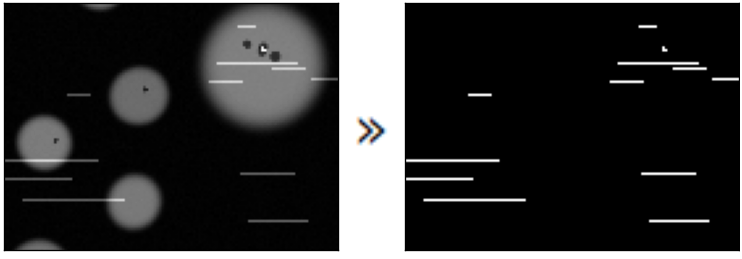

| *Using only one morphological operation followed by a binarization, you should be able to extract the image on the right from the one on the left.* |

Run the next cell to visualize the image you will be working on within this exercise.

Insert your code into the function `detect_hlines(img, n, threshold)`. **Don't code the definition of the morphological operator if it already exists in the library.**

In [ ]:
display_images([test_scratch],['test_scratch'])

In [ ]:
# Function that performs a single morphological filter with some structuring element of size n followed by thresholding
def detect_hlines(img, n, threshold):
    # Initialize output
    output = np.zeros(img.shape)
    
    # YOUR CODE HERE

    return output

Run the next cell to check that the result only consists of binary values **(object = 255, background = 0)** using [`np.unique()`](https://numpy.org/doc/stable/reference/generated/numpy.unique.html).

In [ ]:
# size and threshold
n = 25
threshold = 125

# Check if the image consists of only one value
assert len(np.unique(detect_hlines(test_scratch, n, threshold))) != 1, \
       f"Your image consists of one value: {np.unique(detect_hlines(test_scratch, n, threshold))}. \
       Try changing the values for n and threshold. If this issue persists, you probably made a mistake in your code"

# Check if the image is binary
assert len(np.unique(detect_hlines(test_scratch, n, threshold))) == 2, \
       f"Your image is not binary, it still consists of {len(np.unique(detect_hlines(test_scratch, n, threshold)))} different values. \
       Check your thresholding operation."
    
# Check that the lower binary value is 0
assert np.unique(detect_hlines(test_scratch, n, threshold))[0] == 0, \
       f"The lower binary value should be 0, not {np.unique(detect_hlines(test_scratch, n, threshold))[0]}."

# Check that the upper binary value is 255
assert np.unique(detect_hlines(test_scratch, n, threshold))[1] == 255, \
       f"The upper binary value should be 255, not {np.unique(detect_hlines(test_scratch, n, threshold))[1]}."

# Print victory message
print(f'Well done! Your output image consists of only two values: {{{np.unique(detect_hlines(test_scratch, n, threshold))[0]},{np.unique(detect_hlines(test_scratch, n, threshold))[1]}}}')

In [ ]:
# You can try differnt values of n and threshold here
n = 25
threshold = 125

In [ ]:
output = detect_hlines(test_scratch, n, threshold)

# Display the image 
plt.close('all')
display_images([output], ["detect hlines in test_scratch"])

For **0.5 points** : 

In the following cell, assign `n` (Q17) with the size of the structuring element and `threshold` (Q18) with the threshold you think works best for this task.

In [ ]:
# Assign your values here
n = None
threshold = None
answers['Q17'] = n
answers['Q18'] = threshold

# YOUR CODE HERE


In [ ]:
# Perform a sanity check on n
if not 0 < n < 50: 
    print('The chosen size doesn\'t really make sense.')

In [ ]:
# Perform a sanity check on threshold
if not 0 < threshold < 255: 
    print('The chosen threshold does not really make sense.')

# 7. Combining morphological filters (1 point)

**For 1 point**, using **one or several** of the morphological filters followed by a threshold operation, detect **the 23 round white objects of diameter $20 \pm 4$ pixels (the smaller round objects)** in the image `test_scratch`. Try to preserve their original shapes. Select an appropriate threshold value to get a binary image.

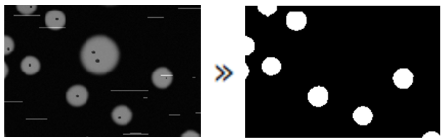

| *Using 3 morphological operations, you can get the image on the right from the image on the left.* |

Insert your code into the function `detect_round(img)`.

💡 *Hints: You can use as many operators as you like with different structuring elements of multiple sizes. That means you need to hard-code the sizes of the structuring elements and the threshold value directly into the code and change them by hand to find the combination that works for you. Design your workflow thinking in terms of simple tasks! For example, what kind of features do you want to keep or get rid of? The effect of each of the operators can be summarized in an effect, e.g. getting rid of big objects.*

In [ ]:
# Function that detects roundish white objects of diamater 20 +/- 4 pixels
def detect_round(img):
    # Initialize the output image
    output = np.zeros(img.shape)

    # YOUR CODE HERE
    
    return output

In [ ]:
# Run the function on the image test_scratch
test_scratch_modified = detect_round(test_scratch)

# Display the images
plt.close('all')
images = [test_scratch, test_scratch_modified]
titles = ['Original', 'Round objects detected']

display_images(images, titles)

Run the next few cells to test if the output has the required properties (background = 0, foreground = 255).

In [ ]:
# Check if the image consists of only one value
if len(np.unique(detect_round(test_scratch))) == 1:
       print(f"WARNING!\nYour image consists of one value: {np.unique(detect_round(test_scratch))}. You probably made a mistake in your code.\n")
# Check if the image is binary
if len(np.unique(detect_round(test_scratch))) != 2:
       print(f"WARNING!\nYour image is not binary, it still consists of {len(np.unique(detect_round(test_scratch)))} different values. Check your thresholding operation.")
else:
    print(f'Good, the image is binary.')

In [ ]:
# Check that the lower binary value is 0
if np.unique(detect_round(test_scratch))[0] != 0: 
    print(f"The lower binary value should be 0, not {np.unique(detect_round(test_scratch))[0]}.")
else:
    print(f'The lower binary value is correct.')

In [ ]:
# Check that the upper binary value is 255
if np.unique(detect_round(test_scratch))[1] != 255: 
    print(f"The upper binary value should be 255, not {np.unique(detect_round(test_scratch))[1]}.")
else:
    # Print victory message
    print(f'The upper binary value is correct.')

# 8. Lantuéjoul's skeleton (3.5 points)

In this part, we're going to implement a 2D skeletonizing algorithm. This process is commonly used in handwritten text recognition, fingerprint validation, and [raster-to-vector](https://en.wikipedia.org/wiki/Image_tracing) conversion. 

## 8.A. Classic Lantuéjoul's algorithm (2 points)

Lantuéjoul's algorithm is an iterative erosion procedure that gives an approximation of the skeleton of an object. The input is a binary image (object = 255, background = 0). The output is also a binary image (skeleton = 255, background = 0).

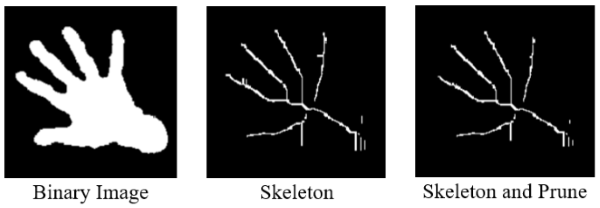

| *Lantuéjoul's algorithm: original image (left), simple Lantuéjoul's algorithm (center) and Lantuéjoul's algorithm with pruning (right).* |

The algorithm makes $N$ successive erosions $e_n$ of the image until the objects are **completely eroded** (stopping condition), using a **$3\times 3$ cross** as a structuring element. As a consequence, the number $N$ of iterations is variable and depends on the size of the objects to erode. In Python, this can be implemented using a while loop.
The skeleton is the union of $N$ partial skeletons $s_n$:

$$\mathrm{skel} =\bigcup_{n \in \lbrace1,2,\dots,N\rbrace} s_{n} = \bigcup_{n \in \lbrace1,2,\dots,N\rbrace}[ e_n - (e_n \circ b) ]\,.$$

Each partial skeleton $s_n$ is obtained by performing a Top-hat operation on an eroded image $e_n$ using a **$3 \times 3$ square** structuring element $b$.

### 8.A.a. Implementing skeletonize (1 point)

**For 1 point**, complete the function `skeletonize` that returns the skeleton and that writes $n$ in the console (use `print(n)`, do not return $n$). Test your code on the image `test_skeleton`.

💡 *Hint:*
- *You can use [`np.count_nonzero(img)`](https://numpy.org/doc/stable/reference/generated/numpy.count_nonzero.html) to get the number of non-zero pixels in `img`.*
- *The correct way to add up two binary images (to get the union above) is to use [`cv.bitwise_or(img_1, img_2)`](https://docs.opencv.org/2.4/modules/core/doc/operations_on_arrays.html#bitwise-or).*

⚠️ **Note: If you don't set the correct stopping condition in the while loop, it can run forever and block the execution of all other code. The cell should generate its output in a few seconds, otherwise you likely created an infinite loop. If this happens you can click on `Kernel` in the toolbar on top and select `Interrupt` to stop the infinite loop. After that, you can adjust your code and rerun the cell.**

In [ ]:
# Function that takes as input a binary image and returns its skeleton
def skeletonize(img):
    # Defining the output image (an array of zeros with the same shape as the input image of type 'uint8')
    output = np.zeros(img.shape, np.uint8)

    # YOUR CODE HERE
    
    return output

In [ ]:
# Run the function on the test image
test_skeleton = skeletonize(test_img)
    
# Define the lists of images and names
images = [test_img, test_skeleton]
titles = ['Original', 'Skeleton']

# Display the images
plt.close('all')
display_images(images, titles)

Run the cell below to verify that the output of your function is binary.

In [ ]:
# Check that the output is binary
if (len(np.unique(test_skeleton)) != 2 or 
    np.max(np.unique(test_skeleton)) != 255 or 
    np.min(np.unique(test_skeleton)) != 0): 
    print('WARNING!\nThe output is not binary with values {0, 255}.')
else:
    print('Good, the output is binary.')

### 8.A.b. Testing skeletonize (1 points)

For **0.5 point**, apply your `skeletonize()` function on the `hands` image and display the result.

In [ ]:
# YOUR CODE HERE


For **0.5 point**:

Q19: In the next cell, assign to the variable `N` the number of erosions it took to generate the skeleton of the `hands` image.

In [ ]:
# Number of erosions to skeletonize the image
N = None
answers['Q19'] = N
# YOUR CODE HERE

In [ ]:
# Perform sanity check on n
if not 0 < N < 200: 
    print('WARNING!\nThe selected number of erosions is not really reasonable.')

## 8.B. Pruning and post-processing (1.5 point)

As you can observe in the `hands` image, the algorithm creates undesired small branches in the skeleton. When the objects have a constant thickness, it is possible to prune the skeleton by constructing a skeleton as the union of the partial skeletons from $M$th to $N$th, with $1 \leq M \leq N$.
The pruned skeleton is the following union of partial skeletons $s_n$:

$$\mathrm{skel}_{\mathrm{pruned}} =\bigcup_{n \in \lbrace M,M+1,\dots,N\rbrace} s_{n} = \bigcup_{n \in \lbrace M,M+1,\dots,N\rbrace}[ e_n - (e_n \circ b) ]\,.$$

This should remove some of the unwanted branches.

**For 1 point**, implement this new method and test in the tasks below.

### 8.B.a. Implementing pruning (1 point)

Program the method `skeletonize_and_prune(img, M)` that returns the pruned skeleton, with $M$ a parameter of the function.

In [ ]:
# Function that takes as input a binary image as well as an integer m and returns its skeleton
# composed of the union from the mth to the last skeleton
def skeletonize_and_prune(img, M):
    # Defining the output image
    output = np.zeros(img.shape, np.uint8)
    
    # YOUR CODE HERE
    
    return output

Run the cell below to verify that the output of your function is binary.

In [ ]:
# Check that the output is binary
check_bin = skeletonize_and_prune(hands, 0)
if (len(np.unique(check_bin)) != 2 or 
    np.max(np.unique(check_bin)) != 255 or 
    np.min(np.unique(check_bin)) != 0):
    print('WARNING!\nThe output is not binary with values [0, 255].')
else:
    print('Nice, the output is binary')

Test your code on the image `hands` and play with the parameter $M$  to see the difference in the skeletons.

💡 *Hint: Note that $M=1$ gives the unpruned skeletonized image. Use this fact to test that the result for $M = 1$ is the same as without pruning.*

In [ ]:
# change the value of M here
M = 1

In [ ]:
pruned_skeleton = skeletonize_and_prune(hands, M)
display_images(
    [hands, pruned_skeleton],
    ['Original Image', 'Pruned Skeleton'])

### 8.B.b. Testing skeletonize and prune (0.5 point)

For **0.5 point**:

Q20: Apply your algorithm on the image `b_letter`, choosing the appropriate $M$ to best capture the shape of the letter B. 

In [ ]:
# change the value of M here
M = 1

In [ ]:
pruned_skeleton = skeletonize_and_prune(b_letter, M)
display_images(
    [b_letter, pruned_skeleton],
    ['Original Image', 'Pruned Skeleton'])

In [ ]:
# Best value for m
M = None
answers['Q20'] = M
# YOUR CODE HERE

In [ ]:
# Perform sanity check on m
if not 0 < M < 50: 
    print('WARNING!\nThe value for m is most likely not correct.')

# 9. Cartoonize your picture! (1.5 point)

Choose a natural picture of your choice from the internet or from your own collection (it shouldn't be too large, otherwise the operations will take a long time). If you're too busy to search for an image yourself you can also use the _natural_image.jpg_ provided in the `images` directory. Using a combination of morphological operators, arithmetic operators, inversion, and threshold operations, gives a cartoon effect to your picture! You can try to make it look like a painting or to give it a distortion effect, explore the possibilities! 

**Note: You can invert an image using [`cv.bitwise_not(img)`](https://docs.opencv.org/2.4/modules/core/doc/operations_on_arrays.html#bitwise-not).**

In [ ]:
orig = cv.cvtColor(cv.imread('images/natural_image.jpg'), cv.COLOR_BGR2RGB)
img = orig

# YOUR CODE HERE

display_images([orig, img], ['Original', 'Cartoonized'])

<font color="red"><b>‼️ IMPORTANT ‼️</b></font>  
**PRINT ALL ANSWERS**

Make sure all questions are answered!

In [ ]:
print(answers)

<div class="alert alert-success">
<p><b>Congratulations on finishing the Filtering-Morphology lab!</b></p>
<p>
Make sure to save your notebook (you might want to keep a copy on your personal computer) and upload both the <b>PDF and notebook file</b> to <a href="https://www.gradescope.com/courses/938339">Gradescope</a>.
</p>
</div>